## Load Simulated Curves

Text(0.5, 0, 'q ($\\AA^{-1}$)')

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

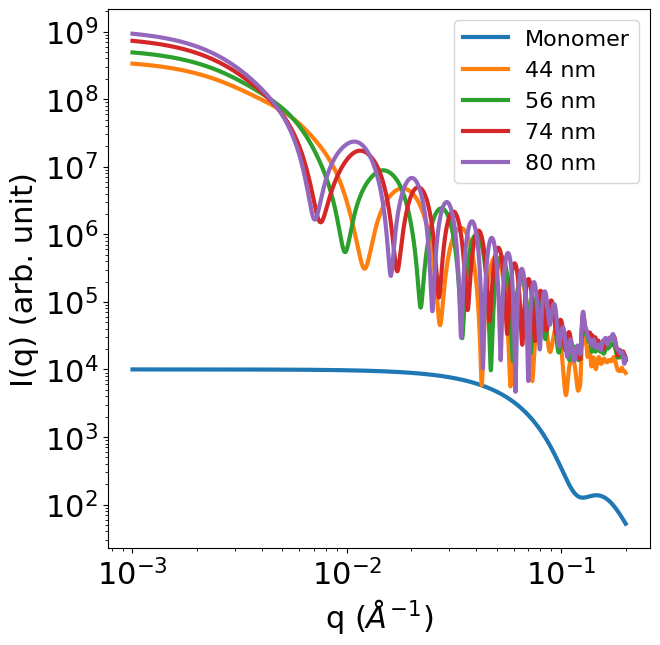

In [1]:
# ------------------------------------------------------------
#  Fit experimental SAXS data with a weighted sum of pre‑simulated curves
#  and a global scale parameter (and optional background).
#  ------------------------------------------------------------
# import required libraries
import sys
sys.path.append('../../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------- #
# 1. Load the experimental data
# ---------------------------------------- #
# Replace 'exp_saxs.txt' with your experimental data file.
# The file is assumed to contain two columns: q (Å⁻¹) and I(q)
exp_file = 'exp_saxs.txt'

exp_data = np.load('../../Data/RhuA/RhuA_Exp_Data.npy')

# ---------------------------------------- #
# 2. Load the simulated data sets
# ---------------------------------------- #
# Provide a list of simulated data files (each with 2 columns: q, I(q)).
sim_files = [
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/RhuA_Monomer.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_15.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_17.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_19.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_21.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_23.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_25.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_27.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_29.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_31.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_33.txt',
    '../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_35.txt',
    # add more files here if desired
]

# Read all simulated curves
sim_q_list = []
sim_I_list = []

for f in sim_files:
    q, I = np.loadtxt(f, unpack=True)
    sim_q_list.append(q)
    sim_I_list.append(I)

# Ensure all curves use the same q-grid
# Use the q of the first file and check consistency
ref_q = sim_q_list[0]
for q in sim_q_list[1:]:
    if not np.allclose(q, ref_q):
        raise ValueError('All simulated data must have the same q values.')
    
# for i in range(len(sim_files)):
#     plt.loglog(sim_q_list[i], sim_I_list[i])

plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
plt.loglog(sim_q_list[0], sim_I_list[0]*1e4, linewidth = 3, label = 'Monomer')
plt.loglog(sim_q_list[2], sim_I_list[2] + 5e3, linewidth = 3, label = '44 nm')
plt.loglog(sim_q_list[4], sim_I_list[4] + 1e4, linewidth = 3, label = '56 nm')
plt.loglog(sim_q_list[7], sim_I_list[7] + 1e4, linewidth = 3, label = '74 nm')
plt.loglog(sim_q_list[8], sim_I_list[8] + 1e4, linewidth = 3, label = '80 nm')
plt.legend(loc='upper right', fontsize = 16)
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')


<BarContainer object of 11 artists>

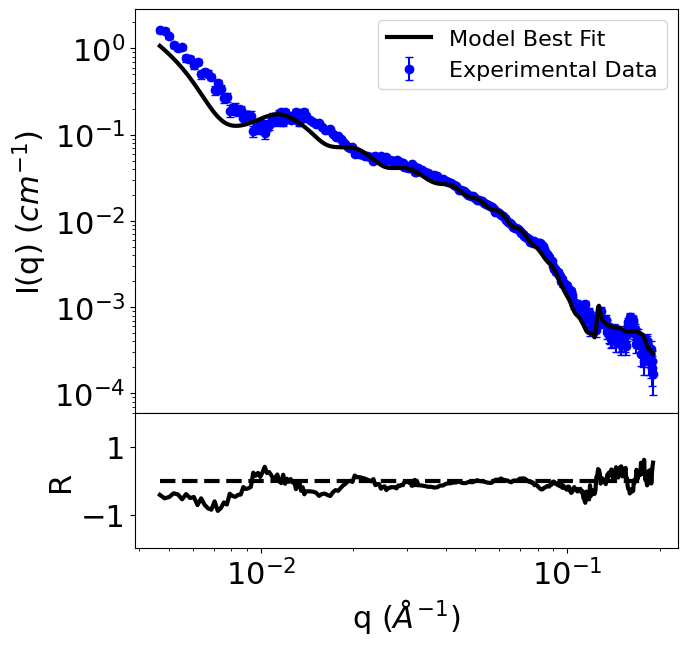

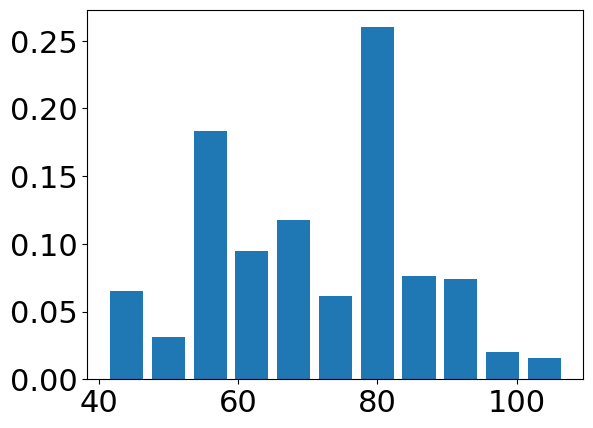

In [2]:
#--- Import required packages ----------------------------------------------------
import sys
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from genetic_algorithm import curve_fitting as cf
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

def save_parameters_txt(parameters, filename="best_solution_scaled.txt"):
    """
    Save parameter dictionary to a text file.

    Parameters
    ----------
    parameters : dict
        Dictionary of parameter names and values
    filename : str
        Output text file name
    """
    
    with open(filename, "w") as f:
        f.write("Best Solution Parameters\n")
        f.write("------------------------\n")
        
        for name, value in parameters.items():
            f.write(f"{name}: {value}\n")

def save_saxs_txt(data, path):
    """
    Save SAXS data (q, I) to a text file.

    Parameters
    ----------
    data : numpy array (N,2)
        SAXS data with columns [q, I]
    filename : str
        Output text file name
    """

    header = "q I"
    np.savetxt(path, data, header=header)

sim_q_list  = []   # list to hold q arrays from each simulation
sim_Iq_list = []   # list to hold I(q) arrays from each simulation

for f in sim_files:
    q_sim, Iq_sim = np.loadtxt(f, unpack=True)
    sim_q_list.append(q_sim)
    sim_Iq_list.append(Iq_sim)

#--- Interpolate all simulated curves onto the experimental q grid ---------------
# (You could also use fitting.convert_data, but numpy.interp is sufficient here)
exp_q = exp_data[:,0]
Iq_interp_list = [np.interp(exp_q, q, Iq) for q, Iq in zip(sim_q_list, sim_Iq_list)]

#--- Define objective function for optimisation ----------------------------------
def objective_function(parameters,
                       param_config,
                       exp_data=None,
                       mode="single",
                       plot=False):
    """
    Parameters: array containing [weight_1, weight_2, ..., weight_N, scale, background]
    param_config: dictionary containing bounds for each parameter
    exp_data: 2‑column array (q, I(q)) of experimental data
    """
    # Scale parameters to sensible ranges
    params = fitting.scale_parameters(parameters, param_config)
    params = list(params.values())
    # Extract weights and scale
    n_weights = len(list(param_config.values())) - 2         # Two extra params: scale & background
    weights   = params[:n_weights]
    scale     = params[-2]
    background= params[-1]

    # Normalise weights so they sum to one (optional but keeps optimisation stable)
    weights = weights / np.sum(weights)

    # Construct the weighted sum of the interpolated simulated curves
    model_Iq = np.zeros_like(exp_q)
    for w, Iq in zip(weights, Iq_interp_list):
        model_Iq += w * Iq

    # Apply global scaling and background shift
    model_Iq = scale * model_Iq + background
    
    exp_data = np.load('../../Data/RhuA/RhuA_Exp_Data.npy')
    # Log‑log error (robust to wide intensity range)
    error = np.mean(np.abs(np.log10(np.abs(exp_data[:, 1])) -
                           np.log10(np.abs(model_Iq))))

    # fitting.run_optimization maximises fitness, so return negative error
    return -error, np.column_stack((exp_q, model_Iq))

#--- Define parameter bounds ------------------------------------------------------
# Example bounds: 3 weights, 2 extra params (scale, background)
param_config = {
    "w1": (1e0, 1e7),          # weight for simulation 1
    "w2": (0.0, 0.7),          # weight for simulation 2
    "w3": (0.0, 1.0),          # weight for simulation 3
    "w4": (0.0, 1.0),          # weight for simulation 3
    "w5": (0.0, 1.0),          # weight for simulation 3
    "w6": (0.0, 1.0),          # weight for simulation 3
    "w7": (0.0, 0.5),          # weight for simulation 3
    "w8": (0.0, 0.5),          # weight for simulation 3
    "w9": (0.0, 0.5),          # weight for simulation 3
    "W10": (0.0, 0.5),
    "W11": (0.0, 0.5),
    "scale": (1e-10, 1e1),     # global scaling factor
    "background": (1e-15, 1e-10) # constant background offset
}

#--- Run optimisation -------------------------------------------------------------
# Adjust batch_size, mutation_rate, iterations as needed
best_solution, fitness_history = fitting.run_optimization(
    exp_data,
    param_config,
    batch_size=100,
    mutation_rate=0.25,
    iterations=1000,
    objective_function=objective_function,
    mode="single"
)

#--- Evaluate best fit -------------------------------------------------------------
best_solution_scaled = fitting.scale_parameters(best_solution, param_config)
score, best_fit = objective_function(best_solution, param_config, exp_data)


# Plotting #
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
q = best_fit[:,0]
ax[0].errorbar(exp_data[:,0], exp_data[:,1], yerr=exp_data[:,2], label = 'Experimental Data', color = 'blue', capsize=3, fmt='o', zorder=0)
ax[0].plot(best_fit[:,0], best_fit[:,1], color = 'k', linewidth=3, label = 'Model Best Fit')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('I(q) ($cm^{-1}$)')
ax[0].set_xticks([])
ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)
model_data = cf.convert_data(exp_data, np.hstack((q.reshape(-1,1), best_fit[:,1].reshape(-1,1))))
model_residual = (np.log(model_data[:,1]/exp_data[:,1]))
ax[1].plot(exp_data[:,0], model_residual, color ='k', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(exp_data[:,0]), np.max(exp_data[:,0]), color='k', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')

# plt.savefig('Intensity.png', dpi=600, bbox_inches="tight")
# save_parameters_txt(best_solution, "Fit_Results.txt")
# save_parameters_txt(param_config, "Fit_Limits.txt")
# save_saxs_txt(best_fit,'/Intensity_Best_Fit.txt')

fig, ax = plt.subplots()
weights = np.array(list(best_solution_scaled.values())[1:12])
weights_norm = weights/np.sum(weights)
#plt.bar([15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35], weights_norm, width=1.75)
plt.bar([44, 50, 56, 62, 68, 74, 80, 86, 92, 98, 104], weights_norm, width=4.75)

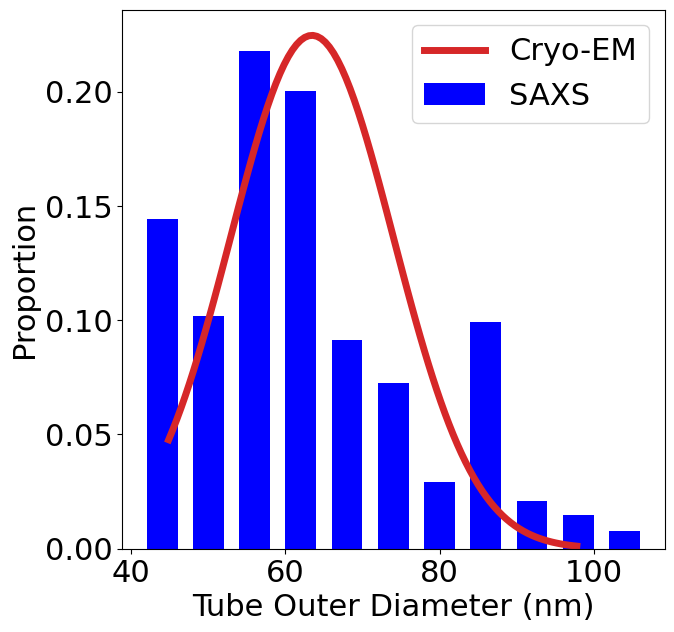

In [3]:
import pandas as pd

plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
cryo_em = pd.read_csv('Cryo_EM.csv').values
best_fit_params = pd.read_csv('best_fit_weighted_sum.csv').values[:,1]
weights = np.array(best_fit_params[1:12])
weights_norm = weights/np.sum(weights)
#plt.bar([15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35], weights_norm, width=1.75)
plt.bar([44, 50, 56, 62, 68, 74, 80, 86, 92, 98, 104], weights_norm, width=4.0, label='SAXS', color='blue')

plt.plot(cryo_em[:,0], cryo_em[:,1]/3.6, linewidth=5, color='C3', label = 'Cryo-EM')


plt.xlabel('Tube Outer Diameter (nm)')
plt.ylabel('Proportion')
plt.legend()

## Simulate Curves

In [32]:
# Import required packages
import sys
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
import math


# ------------------------------------------------------------------
# 1. Load the atomic coordinates of the rectangular‑prism protein
# ------------------------------------------------------------------
# The PDB file should contain a single rectangular prism shaped protein
# of dimensions 7 × 7 × 5 nm (i.e. 70 × 70 × 50 Å).  The file must
# pack a fourth column with the SLD difference of each atom.
# Replace the path with the actual location of your PDB file.
coordinates = Read_PDB.load_pdb('../../Data/PDB/RhuA/1gt7.pdb')
def relative_coordinates(volume):
    '''This function is used to center any set of coordinates at the origin'''
    rel_x = volume[:,0] - np.mean(volume[:,0])
    rel_y = volume[:,1] - np.mean(volume[:,1])
    rel_z = volume[:,2] - np.mean(volume[:,2])
    relative_volume = np.hstack((rel_x.reshape(-1,1), rel_y.reshape(-1,1), rel_z.reshape(-1,1), volume[:,-1].reshape(-1,1)))
    return relative_volume

def rotation_angle(x,z):
    '''This function converts cartesian coordinates to polar'''
    angle = -np.arctan2(z, x)*180/math.pi
    return np.round(angle)


def rotate_coordinates_y(x, z, angle):
    '''This function performs a rigid body rotation around the y-axis'''
    angle = angle*math.pi/180
    x_new = x*np.cos(angle) + z*np.sin(angle)
    z_new = -x*np.sin(angle) + z*np.cos(angle)
    return x_new, z_new

def rotate_coordinates_x(y, z, angle):
    '''This function performs a rigid body rotation around the x-axis'''
    angle = angle*math.pi/180
    y_new = y*np.cos(angle) + z*np.sin(angle)
    z_new = -y*np.sin(angle) + z*np.cos(angle)
    return y_new, z_new

def rotate_coordinates_z(x, y, angle):
    '''This function performs a rigid body rotation around the z-axis'''
    angle = angle*math.pi/180
    x_new = x*np.cos(angle) + y*np.sin(angle)
    y_new = -x*np.sin(angle) + y*np.cos(angle)
    return x_new, y_new

#coordinates = Read_PDB.load_pdb('../Data/PDB/RhuA/1ojr.pdb1') #this function loads the pdb file
coordinates = Read_PDB.load_pdb('../../Data/PDB/RhuA/1gt7.pdb')
coordinates = relative_coordinates(coordinates)
volume = coordinates.copy()
#This rotates the protein around the specifed axis
coordinates[:,1], coordinates[:,2] = rotate_coordinates_x(coordinates[:,1], coordinates[:,2], 180)
coordinates = np.hstack((coordinates[:,0].reshape(-1,1), coordinates[:,2].reshape(-1,1), coordinates[:,1].reshape(-1,1), coordinates[:,-1].reshape(-1,1)))
coordinates[:,0], coordinates[:,1] = rotate_coordinates_z(coordinates[:,0], coordinates[:,1], 0)
volume_rotated = np.hstack((coordinates[:,0].reshape(-1,1), coordinates[:,2].reshape(-1,1), coordinates[:,1].reshape(-1,1), coordinates[:,-1].reshape(-1,1)))
coordinates[:,0], coordinates[:,2] = rotate_coordinates_y(coordinates[:,0], coordinates[:,2], 30 + 180)
volume_rotated = np.hstack((coordinates[:,0].reshape(-1,1), coordinates[:,2].reshape(-1,1), coordinates[:,1].reshape(-1,1), coordinates[:,-1].reshape(-1,1)))
coordinates = volume_rotated


# fig = plt.figure(figsize=(6,6))
# ax = plt.axes(projection='3d')
# ax.scatter(volume_rotated[:,0],volume_rotated[:,1],volume_rotated[:,2], color = 'blue', alpha = 0.1, s = 30)
# ax.set_xlabel('x [$\AA$]')
# ax.set_ylabel('y [$\AA$]')
# ax.set_zlabel('z [$\AA$]')
# ax.set_title('Top Conformation')
building_block = coordinates



# ----- Parameters ---------------------------------------------------------

# Protein sub‑unit dimensions (in Å) – 7 × 7 × 5 nm
SUBUNIT_W = 75.0   # width of the 7 nm face (x‑direction)
SUBUNIT_H = 50.0   # height of the 5 nm face (z‑direction)
SUBUNIT_T = 75.0   # third dimension (y‑direction), not used for geometry

# Tube construction parameters
N_ROTATIONS  = 40                     # number of full helical turns
AXIAL_GAP    = SUBUNIT_H              # axial separation between sub‑units (Å)
CIRCUMF = [13, 15, 17, 19, 21, 23, 25, 27, 29]   # sub‑units per turn

# Simulation setting
N_PAIRWISE    = 10000000   # Keep as required
HISTOGRAM_BIN = 10000
Q = np.geomspace(0.001, 0.2, 3000)   # Q‑vector in Å⁻¹


# -------------------------------------------------------------------------

def build_lattice_coords(N_per_circ, rotations=40,
                         subunit_width=SUBUNIT_W,
                         axial_gap=AXIAL_GAP):
    """
    Build lattice coordinates for a helical tube.
    Each row of the returned array is [dx, dy, dz, rot_x, rot_y, rot_z].
    The translation dx,dy,dz gives the centre of a sub‑unit in Å,
    and rot_y is the rotation applied about the y‑axis (degrees).
    """
    # Radius so that the 7 nm width fits around the circumference
    r = (subunit_width * N_per_circ) / (2.0 * np.pi)

    lattice = []

    for idx in range(N_per_circ * rotations):
        # Position in cylindrical coordinates
        ring_i       = idx % N_per_circ
        roll_i       = idx // N_per_circ
        theta = 2.0 * np.pi * ring_i / N_per_circ
        x = r * np.cos(theta)
        z = r * np.sin(theta)
        y = roll_i * axial_gap

        # Base rotation that keeps the 7x5 face tangent to the tube
        base_rot = -np.arctan2(z, x) * 180.0 / np.pi + 90.0
        # Alternate 180° for successive sub‑units to create up‑down pattern
        if (ring_i % 2) == 1:
            base_rot += 180.0        # flip around the y‑axis

        # Wrap angle to [0, 360)
        base_rot = base_rot % 360.0

        lattice.append([x, y, z, 0.0, base_rot, 0.0])

    return np.array(lattice)


def simulate_tube(N_per_circ, subunit_coords,
                  rotations=40, prop=1.0/len(CIRCUMF)):
    """
    Simulate scattering from a single tube with the given
    number of sub‑units per turn.
    Returns the scaled intensity for use in a mixture.
    """
    lattice_coords = build_lattice_coords(N_per_circ, rotations)
    # Simulate the tube (mode='single' for a single assembly)
    Iq = fitting.simulate_scattering_lattice(subunit_coords,
                                              lattice_coords,
                                              Q,
                                              HISTOGRAM_BIN,
                                              N_PAIRWISE,
                                              mode='multiple')
    # Number of scattering sub‑units in this tube
    N_subunits = N_per_circ * rotations
    # Invariant
    Inv = fitting.invariant(np.column_stack((Q, Iq)))
    # Scale intensity by invariant, sub‑unit count and mixture proportion
    Iq_scaled = fitting.scale_intensity(Iq, Inv, N_subunits, prop)
    #fitting.plot_structure_lattice(subunit_coords, lattice_coords, 1000000)
    return Iq_scaled


# Load the protein sub‑unit coordinates once
subunit_coords = coordinates

# -------------------------------------------------------------------------
# Simulate each tube type, plot, and save
iq_dict = {}
for N_circ in CIRCUMF:
    # Prop is 1/number_of_tubes for an equal mixture
    prop = 1.0 / len(CIRCUMF)
    Iq_scaled = simulate_tube(N_circ, subunit_coords,
                              rotations=N_ROTATIONS,
                              prop=prop)

    iq_dict[N_circ] = Iq_scaled

    # Plot the individual tube scattering curve
    #fitting.plot_intensity(Q, Iq_scaled)


    # Save scattering intensity to a file for later use
    filename = f'../../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_{N_circ}.txt'
    np.savetxt(filename, np.column_stack((Q, Iq_scaled)),
               header='Q(Å⁻¹)  I(q)')

# -------------------------------------------------------------------------
# Construct the total mixture (equal proportions of all tube types)
# Iq_mixture = sum(iq_dict.values())

# # Plot the mixture
# fitting.plot_intensity(Q, Iq_mixture)

# # Save the mixture intensity
# np.savetxt('../sas_llm_results/2026-05-31_13-57-45_RhuA_Tubes_Simulation/Simulated_Data/scattering_intensity_mixture.txt',
#            np.column_stack((Q, Iq_mixture)),
#            header='Q(Å⁻¹)  I(q)')

# # Optionally display plots
# plt.legend()
# plt.show()